# Homogeneous Nucleation

## LaMer model

In many nanoparticle syntheses, the monomer concentration rises (e.g., after precursor injection), reaches a supersaturation threshold, and triggers a short burst of nucleation. After nuclei form, monomer is depleted and nucleation shuts off while particles continue to grow. This qualitative picture is often called the LaMer model.

Before we model time-dependent behavior, we start with classical nucleation theory (CNT): the thermodynamics of forming a small solid nucleus inside a liquid (or solution).

## Units and notation used in this notebook

I will be careful about units because the same symbols can mean “per mole,” “per particle,” or “per volume” in different sources. The following conventions are used:

- Radius: $r$ in meters (m)
- Surface energy (surface tension): $\gamma$ in J/m$^2$
- Volumetric driving force: $\Delta g_v$ in J/m$^3$
- Free energy of formation of a nucleus: $\Delta G_T(r)$ in Joules (J) **per nucleus** ($T$ notates 'Total')
- Critical free energy of formation of a nucleus: $\Delta G_c$ in Joules(J) per nucleus ($c$ notates 'critical')

Sign convention:

- $\Delta g_v = g_s - g_l$ is the solid–liquid Gibbs free energy difference **per unit volume**.
- For nucleation to be thermodynamically favored, the solid must be more stable than the liquid, so
  $$
  \Delta g_v < 0.
  $$

Supersaturation form (solution nucleation, **per particle** convention):
  $$
  \Delta \mu = k_B T \ln S
  $$
-  where $\Delta \mu$ is the chemical potential difference **per particle** (J/particle) and $S$ is supersaturation.
  
- Converting to a volumetric driving force we use the molecular volume $v_m$ (m$^3$/particle):

  $$
  \Delta g_v = -\frac{\Delta \mu}{v_m} = -\frac{k_B T}{v_m}\ln S.
  $$

## Thermodynamics of forming a spherical nucleus

Consider a solid spherical nucleus of radius $r$ forming inside a liquid/solution. Forming the nucleus changes the total Gibbs free energy due to two competing contributions:

1. A **bulk term** proportional to the nucleus volume.
2. A **surface term** proportional to the new interfacial area.

The volume of a sphere is
$$
V = \frac{4}{3}\pi r^3.
$$

Let $g_s$ and $g_l$ denote the Gibbs free energy **per unit volume** of solid and liquid, respectively (J/m$^3$). The *bulk (volume)* contribution is

$$
\Delta G_V(r) = \frac{4}{3}\pi r^3 (g_s - g_l)
= \frac{4}{3}\pi r^3 \Delta g_v.
$$

This however, doesn't tell the whole story; creating a surface requires energy
If $\gamma$ is the solid–liquid interfacial energy (J/m$^2$), then the *surface* contribution is

$$
\Delta G_{\text{s}}(r) = 4\pi r^2 \gamma.
$$

This value is never negative as it always takes energy to create an interface.

Now, the total free energy of forming a nucleus can be described as

$$
\Delta G_T(r) = \Delta G_V(r) + \Delta G_S(r)
= \frac{4}{3}\pi r^3 \Delta G_v + 4\pi r^2 \gamma.
$$

For small $r$, the surface term dominates and $\Delta G(r)$ increases with size. For sufficiently large $r$, the bulk term dominates and $\Delta G(r)$ decreases with size. This competition produces a maximum in $\Delta G(r)$, which is the *nucleation barrier*.

In [14]:
import numpy as np
import pandas as pd
import altair as alt

alt.data_transformers.disable_max_rows()

# limits
xlim = (0.0, 16.0)        # nm
ylim = (-2e-16, 3e-16)    # J

# data
r_m = np.linspace(0.0, xlim[1] * 1e-9, 800)
df = pd.DataFrame({"r_nm": r_m * 1e9, "r_m": r_m})

# sliders
p_log10 = alt.param(
    "log10_abs_dgv", value=np.log10(1.15e8),
    bind=alt.binding_range(min=7.5, max=8.5, step=0.01, name="log10(|Δg_v|)")
)
p_gam = alt.param(
    "gamma", value=0.5,
    bind=alt.binding_range(min=0.2, max=0.8, step=0.01, name="γ (J/m²)")
)

base = (
    alt.Chart(df)
    .add_params(p_log10, p_gam)
    .transform_calculate(
        dg_bulk="(4/3)*PI*pow(datum.r_m,3)*(-pow(10,log10_abs_dgv))",
        dg_surf="4*PI*pow(datum.r_m,2)*gamma",
        dg_tot="((4/3)*PI*pow(datum.r_m,3)*(-pow(10,log10_abs_dgv)))"
               "+(4*PI*pow(datum.r_m,2)*gamma)",
        r_c_nm="(2*gamma/pow(10,log10_abs_dgv))*1e9",
        dg_c="(16*PI*pow(gamma,3))/(3*pow(pow(10,log10_abs_dgv),2))",
    )
)

label_expr = (
    "datum.term=='dg_tot' ? 'Total' : "
    "datum.term=='dg_bulk' ? 'Bulk' : 'Surface'"
)

lines = (
    base.transform_fold(["dg_tot", "dg_bulk", "dg_surf"], as_=["term", "dg"])
    .transform_calculate(term_label=label_expr)
    .mark_line(strokeWidth=2.5, clip=True)
    .encode(
        x=alt.X("r_nm:Q", title="Radius (nm)", scale=alt.Scale(domain=xlim)),
        y=alt.Y(
            "dg:Q",
            title="ΔG (J per nucleus)",
            scale=alt.Scale(domain=ylim),
            axis=alt.Axis(format=".2~e", grid=True),
        ),
        color=alt.Color(
            "term_label:N",
            sort=["Total", "Bulk", "Surface"],
            scale=alt.Scale(
                domain=["Total", "Bulk", "Surface"],
                range=["#1f77b4", "#2ca02c", "#d62728"],
            ),
            legend=alt.Legend(orient="top"),
        ),
        strokeDash=alt.condition(
            "datum.term_label == 'Total'",
            alt.value([1, 0]),
            alt.value([6, 4]),
        ),
        tooltip=[
            alt.Tooltip("r_nm:Q", title="r (nm)", format=".2f"),
            alt.Tooltip("term_label:N", title="Term"),
            alt.Tooltip("dg:Q", title="ΔG (J)", format=".3~e"),
        ],
    )
)

crit = (
    base.transform_filter("datum.r_m == 0")
    .mark_point(size=90, filled=True, color="black")
    .encode(
        x="r_c_nm:Q",
        y="dg_c:Q",
    )
)

chart = (lines + crit).properties(
#     width=720,
#     height=440,
    title="Homogeneous nucleation: ΔG(r)",
)

chart

alt.LayerChart(...)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatLogSlider, FloatSlider


def delta_g_homogeneous_j(
    r_m: np.ndarray,
    delta_gv_j_per_m3: float,
    gamma_j_per_m2: float,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    ΔG for a spherical nucleus in homogeneous nucleation.

    r_m: radius [m]
    delta_gv_j_per_m3: volumetric driving force Δg_v [J/m^3] (should be negative for nucleation)
    gamma_j_per_m2: surface energy γ [J/m^2]
    Returns: (ΔG_V, ΔG_S, ΔG_T) in Joules [J] per nucleus.
    """
    dg_bulk = (4.0 / 3.0) * np.pi * r_m**3 * delta_gv_j_per_m3
    dg_surf = 4.0 * np.pi * r_m**2 * gamma_j_per_m2
    dg_tot = dg_bulk + dg_surf
    return dg_bulk, dg_surf, dg_tot


def critical_radius_m(delta_gv_j_per_m3: float, gamma_j_per_m2: float) -> float:
    """
    Critical radius r_c [m].
    """
    return 2.0 * gamma_j_per_m2 / np.abs(delta_gv_j_per_m3)


def nucleation_barrier_j(delta_gv_j_per_m3: float, gamma_j_per_m2: float) -> float:
    """
    Barrier height ΔG_T(r = r_c) [J] per nucleus (homogeneous nucleation).
    """
    return (16.0 * np.pi * gamma_j_per_m2**3) / (3.0 * delta_gv_j_per_m3**2)


# reference values and plotting window 
DELTA_GV_REF_J_PER_M3 = -1.15e8   # J/m^3
GAMMA_REF_J_PER_M2 = 0.5          # J/m^2

R_C_REF_M = critical_radius_m(DELTA_GV_REF_J_PER_M3, GAMMA_REF_J_PER_M2)
DG_C_REF_J = nucleation_barrier_j(DELTA_GV_REF_J_PER_M3, GAMMA_REF_J_PER_M2)

X_MAX_NM = 2.0 * R_C_REF_M * 1e9  # nm
Y_MIN_J = -1.0 * DG_C_REF_J      # J/nucleus  
Y_MAX_J = 1.5 * DG_C_REF_J        # J/nucleus


def plot_delta_g_fixed_window(delta_gv_j_per_m3: float, gamma_j_per_m2: float, n: int = 1000) -> None:
    """
    Plot ΔG(r)
    """    
    r_m = np.linspace(0.0, X_MAX_NM * 1e-9, n, dtype=np.float64)
    dg_bulk, dg_surf, dg_tot = delta_g_homogeneous_j(r_m, delta_gv_j_per_m3, gamma_j_per_m2)

    r_c_m = critical_radius_m(delta_gv_j_per_m3, gamma_j_per_m2)
    dg_c_j = nucleation_barrier_j(delta_gv_j_per_m3, gamma_j_per_m2)

    plt.figure(figsize=(7, 5))
    plt.plot(r_m * 1e9, dg_tot, label="Total", linewidth=2)
    plt.plot(r_m * 1e9, dg_bulk, "--", label="Bulk", color='g')
    plt.plot(r_m * 1e9, dg_surf, "--", label="Surface", color='r')


    r_c_nm = r_c_m * 1e9
    plt.scatter([r_c_nm], [dg_c_j], zorder=3, s=60)
    plt.annotate(
        r"$(r_c, \Delta G_c)$",
        xy=(r_c_nm, dg_c_j),
        xytext=(r_c_nm * 1.10, dg_c_j * 1.10),
        arrowprops=dict(arrowstyle="->"),
    )
        

    plt.xlim(0.0, X_MAX_NM)
    plt.ylim(Y_MIN_J, Y_MAX_J)
    
    plt.gca().spines['bottom'].set_position('zero')
    
    plt.xlabel("Radius (nm)")
    plt.ylabel(r"$\Delta G$ (J per nucleus)")
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()


def interactive_plot(abs_delta_gv_j_per_m3: float, gamma_j_per_m2: float) -> None:
    plot_delta_g_fixed_window(delta_gv_j_per_m3=-abs_delta_gv_j_per_m3, gamma_j_per_m2=gamma_j_per_m2)


interact(
    interactive_plot,
    abs_delta_gv_j_per_m3=FloatLogSlider(
        value=1.15e8, base=10, min=7.5, max=8.5, step=0.01,
        description="$|\\Delta G_v|$ (J/m$^3$)",
        layout={'width': '400px'},
        style={'description_width': '100px'}
    ),
    gamma_j_per_m2=FloatSlider(
        value=0.5, min=0.2, max=0.8, step=0.01,
        description="$\\gamma$ (J/m$^2$)",
        layout={'width': '400px'},
        style={'description_width': '100px'}
    ),
);

interactive(children=(FloatLogSlider(value=115000000.0, description='$|\\Delta G_v|$ (J/m$^3$)', layout=Layout…

## Critical radius $r_c$ and barrier height $\Delta G_c$

The **critical radius** $r_c$ is defined by the maximum of $\Delta G(r)$:
$$
\left.\frac{\partial\Delta G_T}{\partial r}\right|_{r=r_c} = 0.
$$

Differentiate:
$$
\frac{\partial\Delta G_T}{\partial r}
= 4\pi r^2 \Delta g_v + 8\pi r \gamma.
$$

Set equal to zero and solve for $r \neq 0$:
$$
4\pi r_c^2 \Delta g_v + 8\pi r_c \gamma = 0
\quad\Rightarrow\quad
r_c = -\frac{2\gamma}{\Delta g_v}.
$$

Clusters smaller than $r_c$ tend to shrink because doing so lowers the free energy. Clusters larger than $r_c$ tend to grow, since further growth reduces the free energy even though $\Delta G(r)$ may still be positive. 

The critical radius is of particular importance because it determines the kinetic limitation of nucleation: only clusters that grow large enough to surpass the free energy barrier at $r_c$ are likely to continue growing.

The maximum free energy (the barrier) is $\Delta G_c = \Delta G_T(r_c)$,

$$
\Delta G_c = \frac{16\pi\gamma^3}{3(\Delta g_v)^2}.
$$

## Methods for reducing the critical radius

### Supercooling  and superheating

Near the fusion temperature $T_f$, the bulk driving force can be approximated as linear:

$$
\Delta g_v = \Delta h_v - T \Delta s_v
$$

At $T = T_f$,

$$
\Delta g_{f, v} = 0
\\
\Rightarrow \Delta h_{f, v} = T_f \Delta s_{f, v}
$$

By approximating $\Delta h_v \approx \Delta h_{f,v}$ and $\Delta s_v \approx \Delta s_{f,v}$, we get

$$
\Delta g_v \approx  \Delta h_{f, v} - T\Delta s_{f,v} = \Delta h_{f,v} - \frac{T\Delta h_{f,v}}{T_f} = \Delta h_{f,v} \frac{T_f - T}{T_f}
$$

So,

$$
\Delta g_v = \frac{\Delta h_f}{T_f}\Delta T,
$$

where $\Delta h_f$ is the enthalpy of fusion **per unit volume** (J/m$^3$) and $\Delta T = T - T_f$ (negative below $T_f$). This approximation is valid for $|\Delta T| \ll T_f$.

Substituting into the critical radius gives:

$$
r_c = \frac{2\gamma T_f}{\Delta h_{f,v}}\frac{1}{\Delta T}
$$

and

$$
\Delta G_c = \frac{16 \pi \gamma^3 T_f^2}{3 (\Delta h_{f,v})^2} \frac{1}{(\Delta T)^2}
$$

We notice that $r_c$ and $\Delta G_c$ diminish with increasing supercooling. A similar mathematical derivation for superheating can be done.

### Supersaturation (nucleation from solution)

For nucleation from solution we express the chemical potential driving force in terms of supersaturation, defined here as $S = \frac{c_0}{c_\text{eq}}$,

$$
\Delta \mu = k_B T \ln S \quad \text{(per particle)}.
$$

Converting to a volumetric driving force using the molecular volume $v_m$ (m$^3$/particle):

$$
\Delta g_v = -\frac{\Delta \mu}{v_m} = -\frac{k_B T}{v_m}\ln S.
$$

Substituting into the critical radius gives:

$$
r_c = \frac{2\gamma v_m}{k_B T \ln S}.
$$

and in terms of molar volume, $V_M$,

$$
\Delta G_c = \frac{16 \pi \gamma^3 V_M^2}{3(RT\ln(S))^2}
$$

This highlights three experimentally relevant parameters that affect nucleation:
- surface/interfacial energy $\gamma$ (tuned by choice of solvent and ligand)
- temperature $T$
- supersaturation $S$

## Nucleation rate and the free energy barrier

Thermodynamics tells us the shape of $\Delta G$, but not how quickly nuclei appear. CNT models the **nucleation rate** $J$ (nuclei formed per unit volume per unit time) as being suppressed exponentially by the free energy barrier:

$$
J = J_0 \exp\!\left(-\frac{\Delta G_c}{k_B T}\right),
$$

where $k_B$ is Boltzmann’s constant and $J_0$ is a kinetic prefactor$^*$. Using the CNT barrier height,

$$
\Delta G_c = \frac{16\pi\gamma^3}{3(\Delta g_v)^2},
$$

we obtain

$$
J = J_0 \exp\!\left(
-\frac{16\pi\gamma^3}{3(\Delta g_v)^2 k_B T}
\right).
$$

For solution nucleation we may substitute

$$
\Delta g_v = -\frac{k_B T}{v_m}\ln S,
$$

which gives

$$
J = J_0 \exp\!\left(
-\frac{16\pi\gamma^3 v_m^2}{3 k_B^3 T^3 (\ln S)^2}
\right).
$$

Because $J$ depends exponentially on the barrier, small changes in $\gamma$, $T$, or $S$ can change the nucleation rate by many orders of magnitude. This sensitivity is one of the reasons nanoparticle synthesis can produce either no particles or a sudden burst of nuclei depending on subtle experimental conditions.

---
<p style="font-size:0.8em">
$^* J_0$ is the product of the number of nucleation sites, $N_S$, the rate at which molecules attach to the nucleus $j$, and the Zeldovich factor $Z$ which gives the probability that a nucleus at the top of the energy barrier to form a new phase rather than dissolve.
</p>

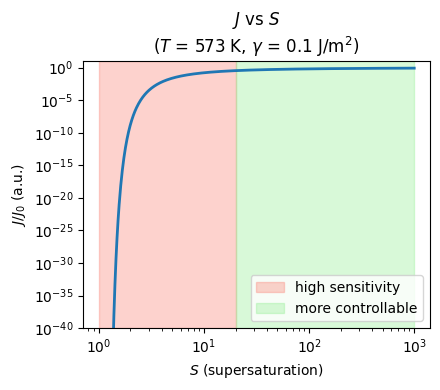

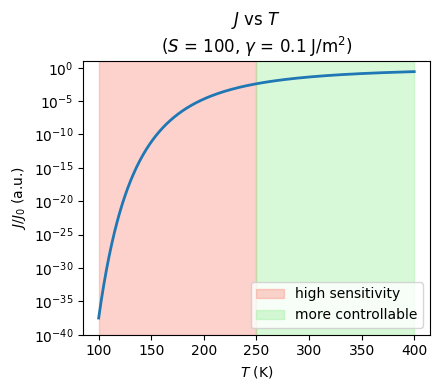

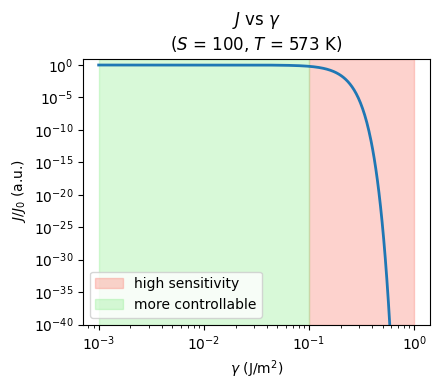

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# physical constants
k_B = 1.380649e-23  # J/K

# material parameters
v_m = 1.696e-29     # m^3 per Au atom (molecular volume / growth unit)
gamma_ref = 0.1     # J/m^2
T_ref = 573.0       # K
S_ref = 100.0

# plot settings
J_MIN = 1e-40
J_MAX = 10

def nucleation_rate_relative(S, T, gamma):
    """
    Relative CNT nucleation rate J/J0 (dimensionless).

    Uses:
        Δg_v = -(k_B T / v_m) ln S
        J/J0 = exp(-ΔG_c / (k_B T))
    """
    lnS = np.log(S)

    exponent = (
        16 * np.pi * gamma**3 * v_m**2
        / (3 * k_B**3 * T**3 * lnS**2)
    )

    return np.exp(-exponent)

# J vs supersaturation S
S = np.logspace(0.01, 3, 600)
J = nucleation_rate_relative(S, T_ref, gamma_ref)

plt.figure(figsize=(4.5, 4))
plt.plot(S, J, linewidth=2)

plt.xscale("log")
plt.yscale("log")
plt.ylim(J_MIN, J_MAX)

# Shaded regions
plt.axvspan(1, 20, color="salmon", alpha=0.35, label="high sensitivity")
plt.axvspan(20, 1000, color="lightgreen", alpha=0.35, label="more controllable")

plt.xlabel("$S$ (supersaturation)")
plt.ylabel("$J/J_0$ (a.u.)")
plt.title("$J$ vs $S$\n($T$ = 573 K, $\\gamma$ = 0.1 J/m$^2$)")
plt.legend()
plt.tight_layout()
plt.show()


# J vs temperature T
T = np.linspace(100, 400, 600)
J = nucleation_rate_relative(S_ref, T, gamma_ref)

plt.figure(figsize=(4.5, 4))
plt.plot(T, J, linewidth=2)

plt.yscale("log")
plt.ylim(J_MIN, J_MAX)

plt.axvspan(100, 250, color="salmon", alpha=0.35, label="high sensitivity")
plt.axvspan(250, 400, color="lightgreen", alpha=0.35, label="more controllable")


plt.xlabel("$T$ (K)")
plt.ylabel("$J/J_0$ (a.u.)")
plt.title("$J$ vs $T$\n($S$ = 100, $\\gamma$ = 0.1 J/m$^2$)")
plt.legend()
plt.tight_layout()
plt.show()


# J vs surface energy Gamma
gamma = np.logspace(-3, 0, 600)
J = nucleation_rate_relative(S_ref, T_ref, gamma)

plt.figure(figsize=(4.5, 4))
plt.plot(gamma, J, linewidth=2)

plt.xscale("log")
plt.yscale("log")
plt.ylim(J_MIN, J_MAX)


plt.axvspan(0.1, 1.0, color="salmon", alpha=0.35, label="high sensitivity")
plt.axvspan(0.001, 0.1, color="lightgreen", alpha=0.35, label="more controllable")


plt.xlabel("$\\gamma$ (J/m$^2$)")
plt.ylabel("$J/J_0$ (a.u.)")
plt.title("$J$ vs $\\gamma$\n($S$ = 100, $T$ = 573 K)")
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()

# Heterogeneous nucleation

In many real syntheses, nucleation occurs on container walls, impurities, seeds, or other surfaces (i.e., heterogenously). In heterogeneous nucleation, the barrier height is reduced relative to homogeneous nucleation by a geometric factor $f(\theta)$ that depends on the contact angle $\theta$:

$$
\Delta G_{c,\text{hetero}} = f(\theta)\,\Delta G_{c,\text{homo}},
\qquad 0 \le f(\theta) \le 1.
$$

This reduction can strongly increase the nucleation rate, because the rate depends exponentially on the barrier.

In [5]:
import numpy as np
import matplotlib.pyplot as plt

G_s = 0
G_l = 1.15e8  # J/m^3
gamma = 0.5  # J/m^2
delta_Gv = G_s - G_l  # negative
# theta = 60 * np.pi / 180  # radians


def plot_gc_homo_hetero(theta_degrees: float = 90) -> None:
    r = np.linspace(0, 20e-9, 1000)
    theta_radian = theta_degrees * np.pi / 180

    delta_G_bulk = 4/3 * np.pi * r**3 * (delta_Gv)
    delta_G_surface = 4 * np.pi * r**2 *  gamma
    geometric_factor = 0.25 * (2 + np.cos(theta_radian)) * (1 -       np.cos(theta_radian)) ** 2

    delta_G_homo = delta_G_bulk + delta_G_surface
    delta_G_hetero = geometric_factor * delta_G_homo

    r_c = -2 * gamma / delta_Gv
    delta_G_homo_c = (16 * np.pi * gamma**3) / (3 *             delta_Gv**2)
    delta_G_hetero_c = delta_G_homo_c * geometric_factor

    plt.figure(figsize=(7,5))

    plt.plot(r*1e9, delta_G_homo, label="Homo", linewidth=2, color = 'C0')
    plt.plot(r*1e9, delta_G_hetero, label="Hetero", linewidth=2, color="C1")

    # Critical radius marker
    plt.gca().spines['bottom'].set_position('zero')
    plt.scatter([r_c*1e9], [delta_G_homo_c], color="C0", zorder=2, s=50)
    plt.scatter([r_c*1e9], [delta_G_hetero_c], color="C1", zorder=2, s=50)
    
    plt.annotate(f"$f(\\theta) = {geometric_factor:.2f}$", (1, 0.07 * delta_G_surface.max()))

    plt.xlabel("Radius (nm)")
    plt.ylabel("$\\Delta G$ (J)")
    plt.xlim(0, 1.8*r_c*1e9)
    plt.ylim(
        0.015 * delta_G_bulk.min(),
        0.08 * delta_G_surface.max()
    )

    plt.legend()
    plt.tight_layout()
    plt.show()
    
interact(
    plot_gc_homo_hetero,
    theta_degrees=FloatSlider(
        value=90, min=0, max=180, step=0.1,
        description="$\\theta$ (°)",
        layout={'width': '400px'},
        style={'description_width': '100px'}
    ),
);

interactive(children=(FloatSlider(value=90.0, description='$\\theta$ (°)', layout=Layout(width='400px'), max=1…

We notice that heterogenuos nucleation has an energy barrier lower than that of an equivalent homogenuos nucleation; however, the critical radius remains the same for both.